Project Summary

This project explores the OSMI 2014 "Mental Health in Tech Survey," which captures how tech-industry employees perceive and experience mental health in the workplace: whether they have sought treatment, whether they feel comfortable disclosing a condition, whether their employer offers benefits or protects anonymity, and how factors like family history, work interference, company size, and manager/coworker comfort relate to seeking treatment.

The raw data (1,259 responses × 27 columns) is messy: Age contains impossible values (negative numbers, and one response of 99999999999), Gender is free text with 49 distinct spellings, and state, self_employed, and work_interfere all contain missing values that are informative rather than random. A separate cleaning notebook handles this — it fixes Age outliers, normalizes Gender into Male/Female/Other, fills missing values with meaningful defaults, and removes 4 duplicate responses — producing a cleaned dataset of 1,255 rows used throughout this analysis.

The EDA covers 20 visuals spanning demographics (age, gender, country) and every major workplace attitude/policy variable compared against treatment-seeking (family history, work interference, company size, remote work, self-employment, benefits, care options, wellness programs, seek-help resources, anonymity, leave difficulty, coworker and supervisor comfort), plus a correlation heatmap and pair plot. The goal is to surface patterns an HR/People-Ops team could act on: which groups are under-supported, and which workplace policies correlate most strongly with employees actually seeking help.

Problem Statement

Mental health remains under-discussed in tech workplaces, and many companies don't know whether their policies (benefits, anonymity protections, leave policy, manager/coworker support) actually correlate with employees seeking treatment. Using the 2014 OSMI survey, this project analyzes demographic and workplace attitude data to understand the current state of mental health awareness and support in the tech industry, and to identify which factors are most associated with an employee seeking treatment for a mental health condition.

Business Objective

Identify the demographic and workplace factors most strongly associated with an employee seeking mental health treatment, so that an organization can prioritize the policies (benefits, anonymity, manager/coworker comfort, leave ease) most likely to increase help-seeking and reduce the stigma tied to disclosing a mental health condition at work.

In [2]:
import pandas as pd

df = pd.read_csv("cleaned_survey_readable.csv")

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1255, 26)


,Timestamp,Age,Gender,Country,State,Self Employed,Family History,Treatment,Work Interfere,No Employees,...,Anonymity,Leave,Mental Health Consequence,Phys Health Consequence,Coworkers,Supervisor,Mental Health Interview,Phys Health Interview,Mental Vs Physical,Obs Consequence
0,2014-08-27 11:29:31,37,Female,United States,IL,Unknown,No,Yes,Often,6-25,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,2014-08-27 11:29:37,44,Male,United States,IN,Unknown,No,No,Rarely,More than 1000,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,2014-08-27 11:29:44,32,Male,Canada,Not Specified,Unknown,No,No,Rarely,6-25,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,2014-08-27 11:29:46,31,Male,United Kingdom,Not Specified,Unknown,Yes,Yes,Often,26-100,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,2014-08-27 11:30:22,31,Male,United States,TX,Unknown,No,No,Never,100-500,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


### 1. What is the age distribution of employees who participated in the survey?

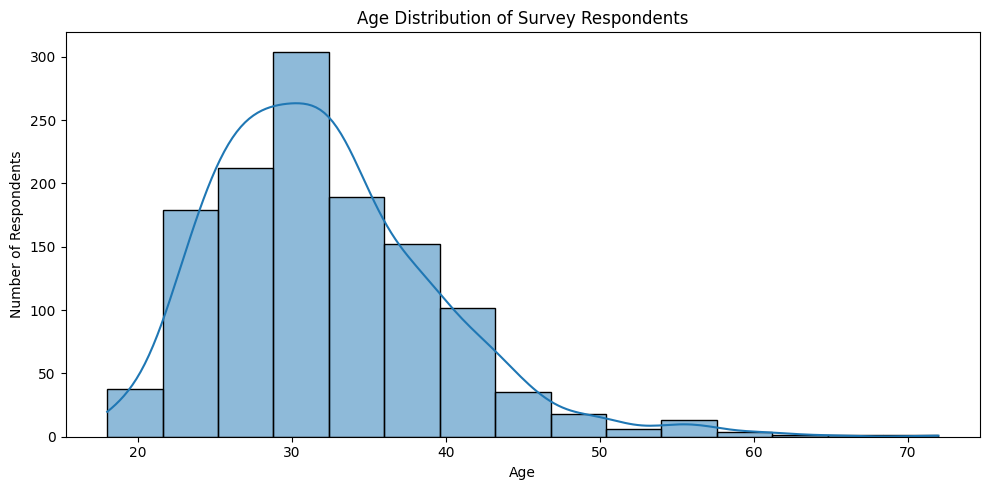

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Age',
    bins=15,
    kde=True
)

plt.title('Age Distribution of Survey Respondents')
plt.xlabel('Age')
plt.ylabel('Number of Respondents')

plt.tight_layout()
plt.show()

Finding:
The respondents are mainly concentrated between 25 and 40 years, with the highest concentration around 30–32 years. The distribution is right-skewed, with fewer respondents above 45 and only a small number in the 50–70 age range.

Visual used: Histogram with KDE — suitable for showing the frequency and overall shape of a numerical variable like age.

Conclusion:
The survey sample is largely represented by young to mid-career professionals.

Q2. What is the gender distribution of the survey respondents?

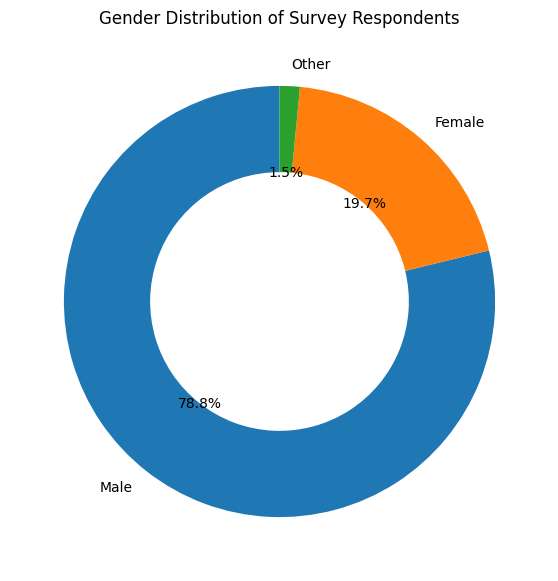

In [7]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.title('Gender Distribution of Survey Respondents')
plt.show()

In [ ]:
Finding :

The survey is heavily male-dominated, with 78.8% Male respondents, followed by 19.7% Female and 1.5% Other.

In [ ]:
Q3. Which countries have the highest number of survey respondents?

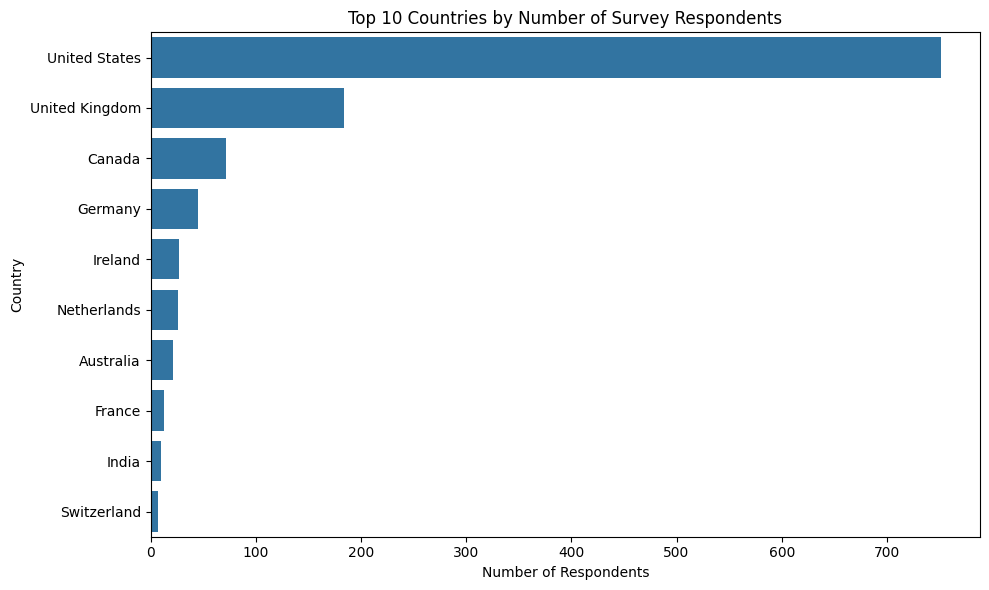

In [8]:
country_counts = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title('Top 10 Countries by Number of Survey Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

Finding

The United States dominates the survey responses, with 751 respondents, followed by the United Kingdom (185) and Canada (72). The remaining countries contribute considerably fewer responses.

Q4. How common is a family history of mental illness among survey respondents?

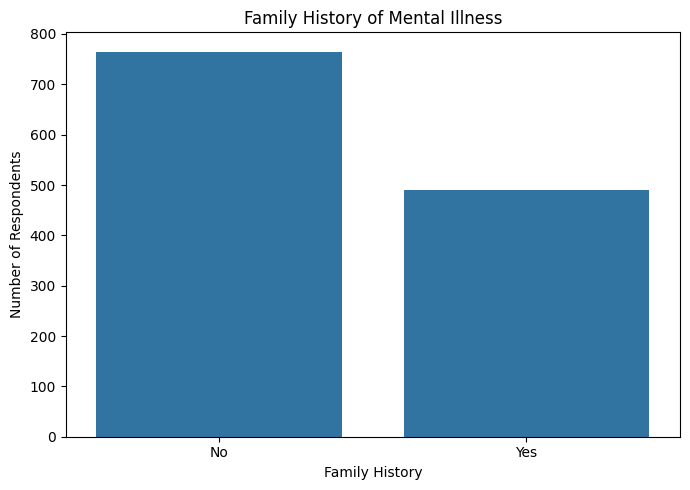

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Family History'
)

plt.title('Family History of Mental Illness')
plt.xlabel('Family History')
plt.ylabel('Number of Respondents')

plt.tight_layout()
plt.show()

Finding

Most respondents do not report a family history of mental illness. Around 760 respondents selected “No,” compared with about 490 who selected “Yes.” So, roughly 60% of respondents reported no family history, while about 40% reported a family history.

Q5. How many respondents have sought treatment for a mental health condition?

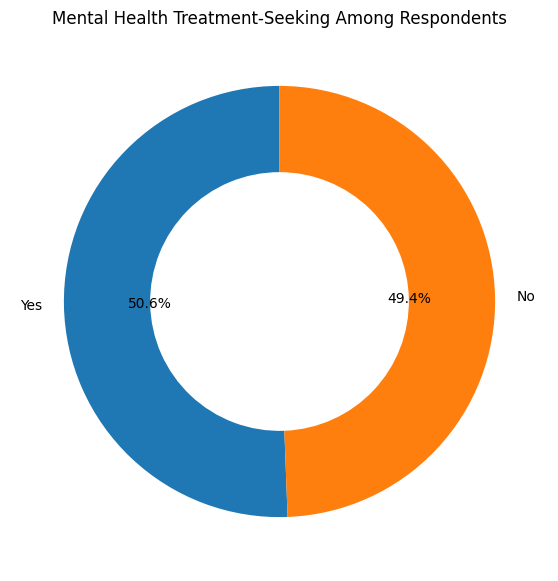

In [10]:
treatment_counts = df['Treatment'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    treatment_counts,
    labels=treatment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.title('Mental Health Treatment-Seeking Among Respondents')

plt.show()

Finding

The treatment-seeking responses are almost evenly split: 50.6% of respondents reported that they had sought treatment, while 49.4% reported that they had not.

This shows that treatment-seeking is not strongly concentrated in either group within this survey sample.

Q6. Is family history associated with seeking mental health treatment?

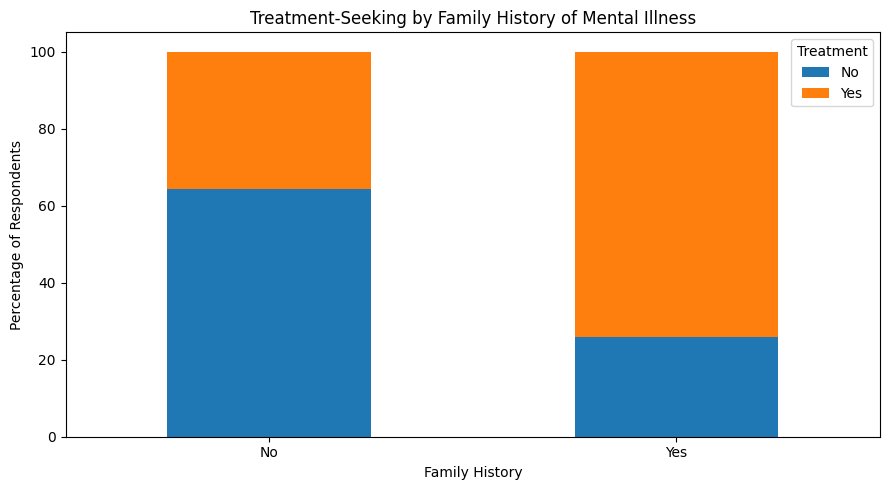

In [11]:
treatment_family = pd.crosstab(
    df['Family History'],
    df['Treatment'],
    normalize='index'
) * 100

treatment_family.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.title('Treatment-Seeking by Family History of Mental Illness')
plt.xlabel('Family History')
plt.ylabel('Percentage of Respondents')
plt.legend(title='Treatment')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Finding

The difference is clear: respondents with a family history show a much higher treatment-seeking rate. Around 74% of them reported seeking treatment, compared with about 36% among those without a family history.

This suggests a noticeable association between family history and treatment-seeking in the survey.

Q7. Among respondents with a mental health condition, how often does it interfere with their work?

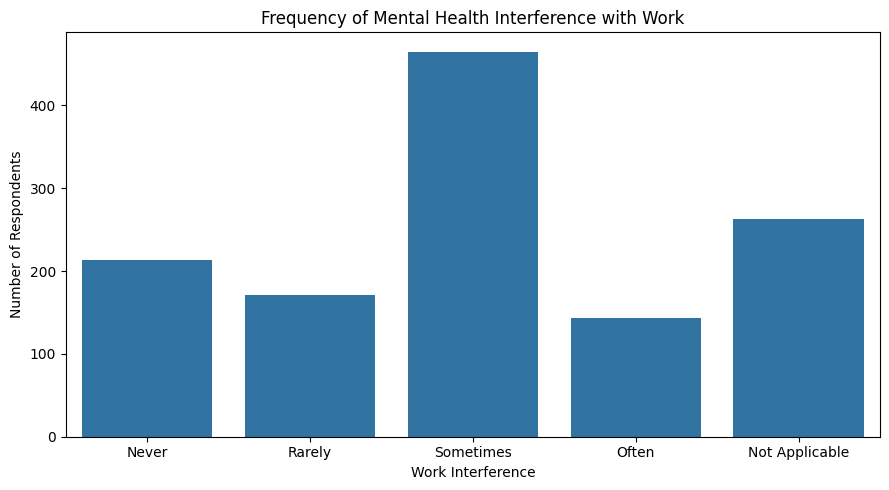

In [12]:
work_interfere_counts = df['Work Interfere'].value_counts()

order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not Applicable']

work_interfere_counts = work_interfere_counts.reindex(order).dropna()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=work_interfere_counts.index,
    y=work_interfere_counts.values
)

plt.title('Frequency of Mental Health Interference with Work')
plt.xlabel('Work Interference')
plt.ylabel('Number of Respondents')

plt.tight_layout()
plt.show()

Finding

The largest group reported that mental health sometimes interferes with their work. A smaller group reported often, while many respondents reported never or rarely. The Not Applicable group is also substantial because this question is conditional on having a mental health condition.

Q8. How does company size relate to mental health treatment-seeking?

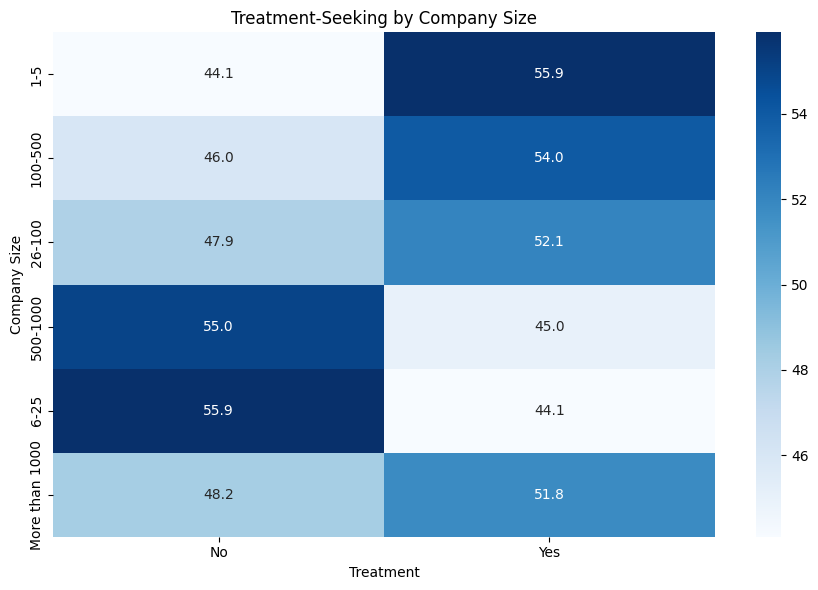

In [13]:
treatment_company = pd.crosstab(
    df['No Employees'],
    df['Treatment'],
    normalize='index'
) * 100

plt.figure(figsize=(9, 6))

sns.heatmap(
    treatment_company,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Treatment-Seeking by Company Size')
plt.xlabel('Treatment')
plt.ylabel('Company Size')

plt.tight_layout()
plt.show()

Finding

Treatment-seeking varies across company sizes, but the differences are relatively small. The 1–5 employee group has the highest treatment rate at 55.9%, while the 6–25 employee group has the lowest at 44.1%. The larger company groups generally remain close to the 45–54% range.

Q9. Does working remotely relate to mental health treatment-seeking?

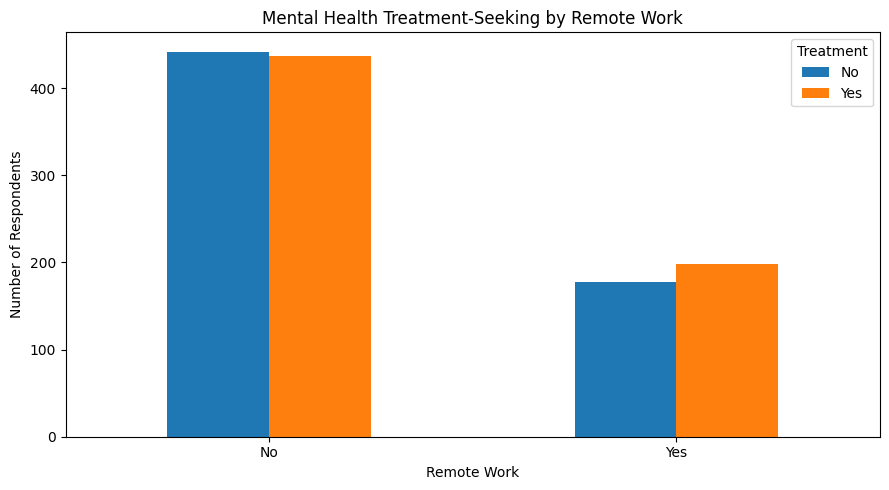

In [14]:
remote_treatment = pd.crosstab(
    df['Remote Work'],
    df['Treatment']
)

remote_treatment.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Mental Health Treatment-Seeking by Remote Work')
plt.xlabel('Remote Work')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')

plt.tight_layout()
plt.show()

Finding

Among non-remote workers, treatment responses are almost evenly split, with slightly more reporting No treatment than Yes. Among remote workers, the pattern reverses, with slightly more respondents reporting Yes treatment than No.

The difference is noticeable but not very large, so remote work alone does not show a strong separation in treatment-seeking in this sample.

Q10. Does working for a tech company relate to mental health treatment-seeking?

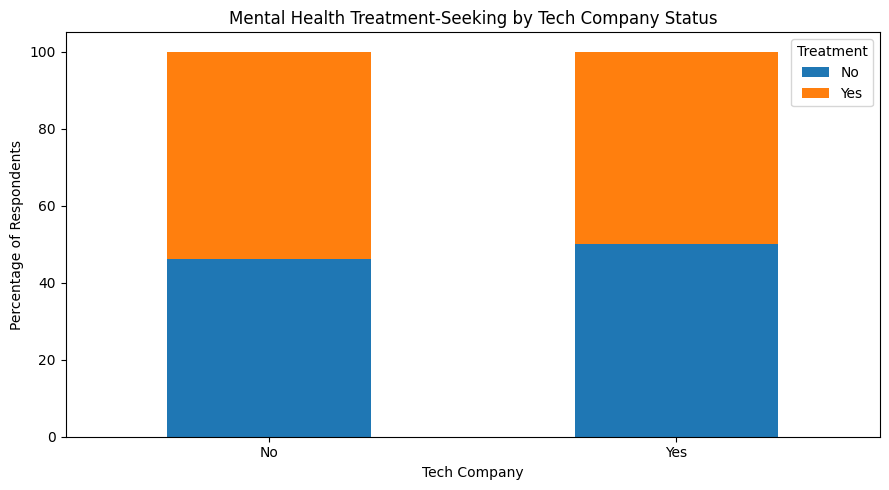

In [15]:
tech_treatment = pd.crosstab(
    df['Tech Company'],
    df['Treatment'],
    normalize='index'
) * 100

tech_treatment.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.title('Mental Health Treatment-Seeking by Tech Company Status')
plt.xlabel('Tech Company')
plt.ylabel('Percentage of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')

plt.tight_layout()
plt.show()

Finding

Treatment-seeking is fairly similar across both groups. Respondents from non-tech companies show about 53% treatment-seeking, compared with about 50% among tech-company employees.

The difference is relatively small, suggesting that tech-company status does not show a strong relationship with treatment-seeking in this sample.

Q11. How widely do employers provide mental health benefits?

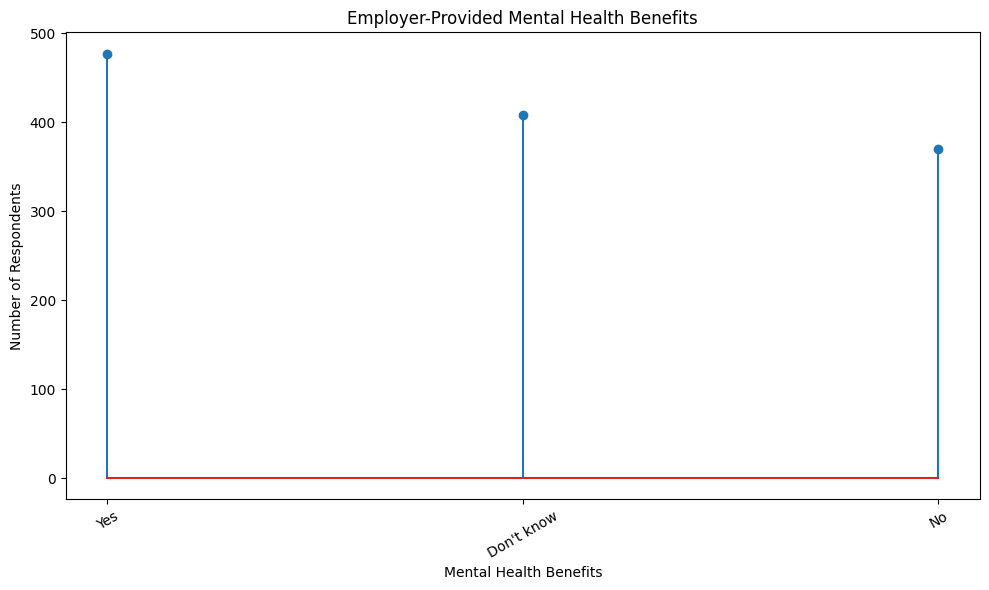

In [17]:
benefit_counts = df['Benefits'].value_counts()

plt.figure(figsize=(10, 6))

plt.stem(
    benefit_counts.index,
    benefit_counts.values
)

plt.title('Employer-Provided Mental Health Benefits')
plt.xlabel('Mental Health Benefits')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Finding

Around 38% of respondents reported that their employer provides mental health benefits, while about 33% said they did not know and 29% reported that their employer did not provide them.

This shows that awareness is also an issue, with a sizeable share of employees unsure whether such benefits are available.

Q12. Are employees aware of the mental health care options provided by their employers?

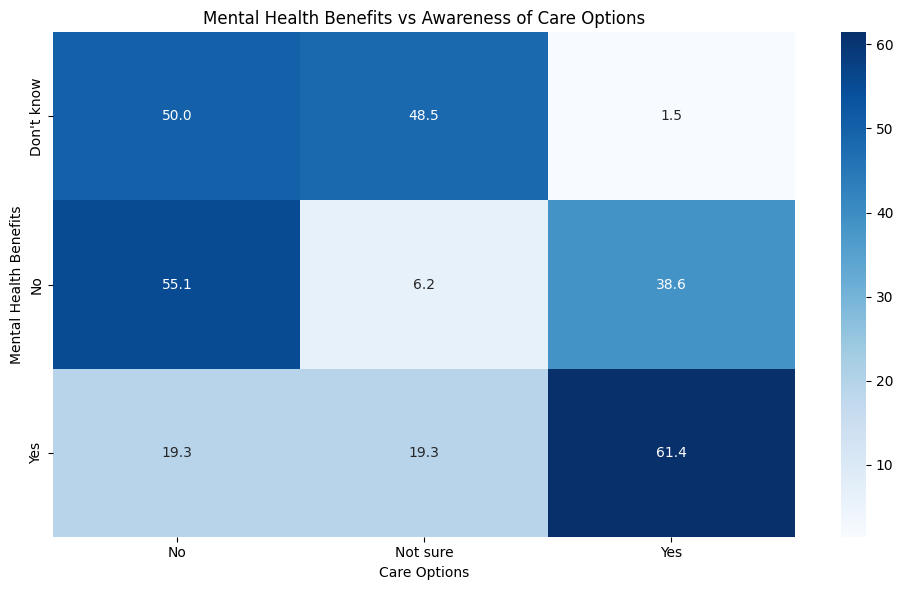

In [18]:
care_awareness = pd.crosstab(
    df['Benefits'],
    df['Care Options'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 6))

sns.heatmap(
    care_awareness,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Mental Health Benefits vs Awareness of Care Options')
plt.xlabel('Care Options')
plt.ylabel('Mental Health Benefits')

plt.tight_layout()
plt.show()

Finding

Among respondents whose employers provide mental health benefits, 61.4% know about the available care options. In comparison, only 38.6% of respondents whose employers do not provide benefits reported knowing about care options.

A large share of respondents whose employers do not provide benefits (55.1%) also reported not knowing about available care options.

Q13. How easy is it for employees to take medical leave for a mental health condition?

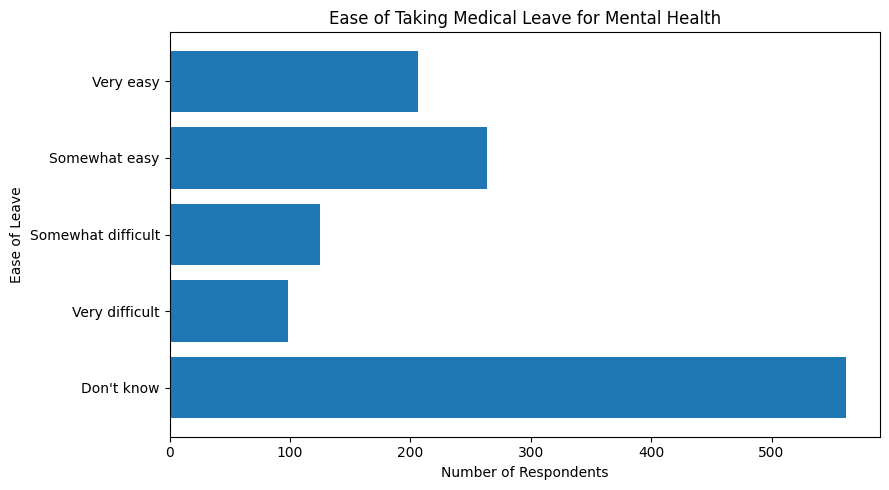

In [19]:
leave_order = [
    'Very easy',
    'Somewhat easy',
    'Somewhat difficult',
    'Very difficult',
    "Don't know"
]

leave_counts = (
    df['Leave']
    .value_counts()
    .reindex(leave_order)
    .dropna()
)

plt.figure(figsize=(9, 5))

plt.barh(
    leave_counts.index,
    leave_counts.values
)

plt.title('Ease of Taking Medical Leave for Mental Health')
plt.xlabel('Number of Respondents')
plt.ylabel('Ease of Leave')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Finding

The largest group, over 550 respondents, selected "Don't know" about how easy it is to take medical leave for mental health. Among those who gave a clear answer, "Somewhat easy" is the most common response, followed by "Very easy."

This suggests that awareness about the process for taking mental-health-related leave is a significant gap in the survey.

Q14. Do employees perceive negative consequences from discussing mental health with their employer?

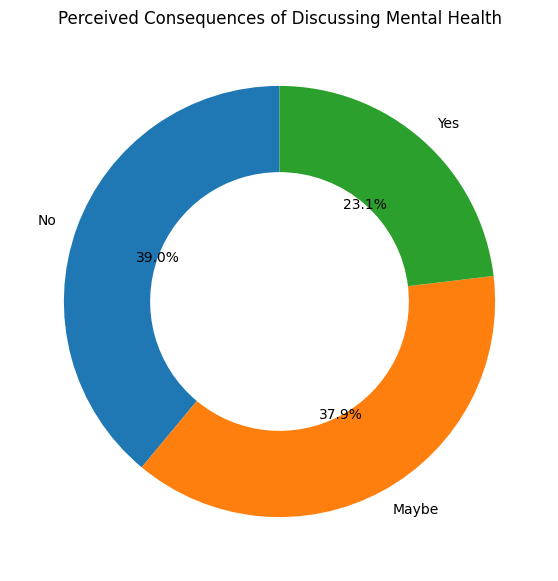

In [20]:
consequence_counts = df['Mental Health Consequence'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    consequence_counts,
    labels=consequence_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.title('Perceived Consequences of Discussing Mental Health')
plt.show()

Finding

The responses are fairly divided: 39.0% believe discussing a mental health issue would have no negative consequences, while 37.9% answered Maybe and 23.1% answered Yes.

So, although the largest single group sees no negative consequences, a substantial 61% either sees a possible or definite risk.

Q15. How willing are employees to discuss mental health with coworkers and supervisors?

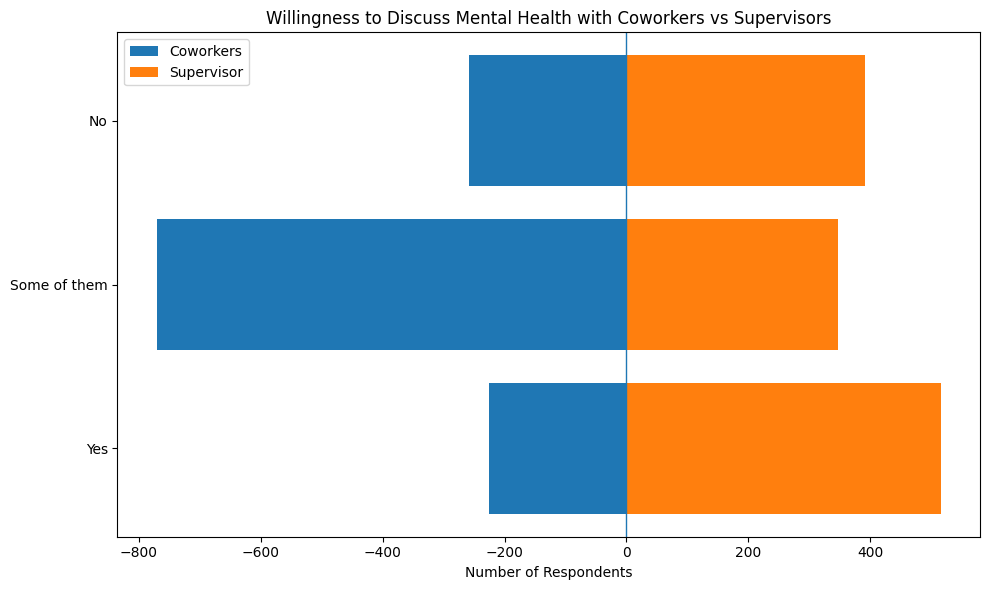

In [21]:
discussion = pd.DataFrame({
    'Coworkers': df['Coworkers'].value_counts(),
    'Supervisor': df['Supervisor'].value_counts()
}).fillna(0)

discussion = discussion.reindex(['Yes', 'Some of them', 'No'])

y = np.arange(len(discussion))

plt.figure(figsize=(10, 6))

plt.barh(
    y,
    -discussion['Coworkers'],
    label='Coworkers'
)

plt.barh(
    y,
    discussion['Supervisor'],
    label='Supervisor'
)

plt.axvline(0, linewidth=1)

plt.yticks(y, discussion.index)
plt.xlabel('Number of Respondents')
plt.title('Willingness to Discuss Mental Health with Coworkers vs Supervisors')

plt.legend()
plt.tight_layout()
plt.show()

Finding

Employees are more likely to select “Some of them” when discussing mental health with coworkers, while “Yes” is the largest response for supervisors. The chart also shows that fewer respondents are completely comfortable discussing mental health with coworkers than with supervisors.

Q16. Is observing negative consequences for coworkers associated with willingness to discuss mental health?

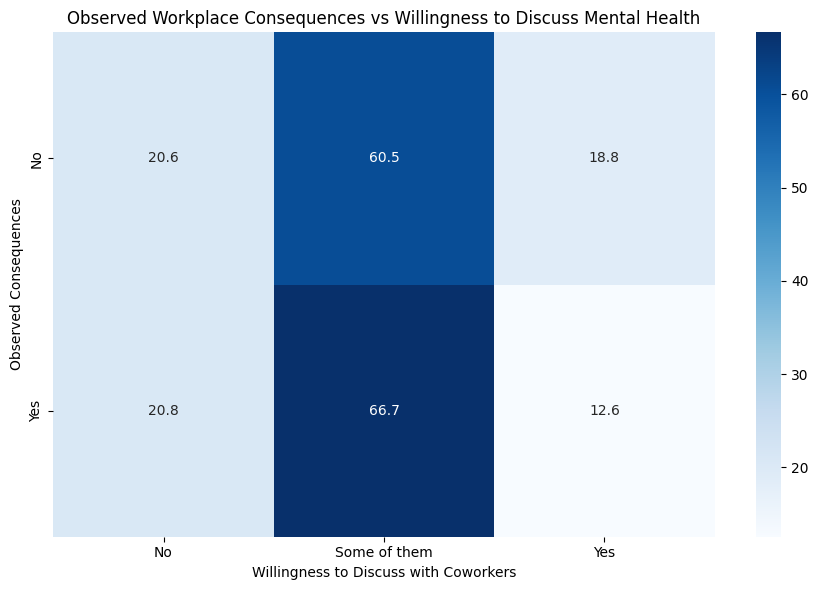

In [22]:
obs_discussion = pd.crosstab(
    df['Obs Consequence'],
    df['Coworkers'],
    normalize='index'
) * 100

plt.figure(figsize=(9, 6))

sns.heatmap(
    obs_discussion,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Observed Workplace Consequences vs Willingness to Discuss Mental Health')
plt.xlabel('Willingness to Discuss with Coworkers')
plt.ylabel('Observed Consequences')

plt.tight_layout()
plt.show()

Finding

Among respondents who had observed negative consequences for coworkers, 66.7% selected “Some of them” when asked about discussing mental health with coworkers, while 12.6% selected “Yes.”

Among those who had not observed negative consequences, 60.5% selected “Some of them” and 18.8% selected “Yes.”

Q17. How does treatment-seeking vary across different age groups?

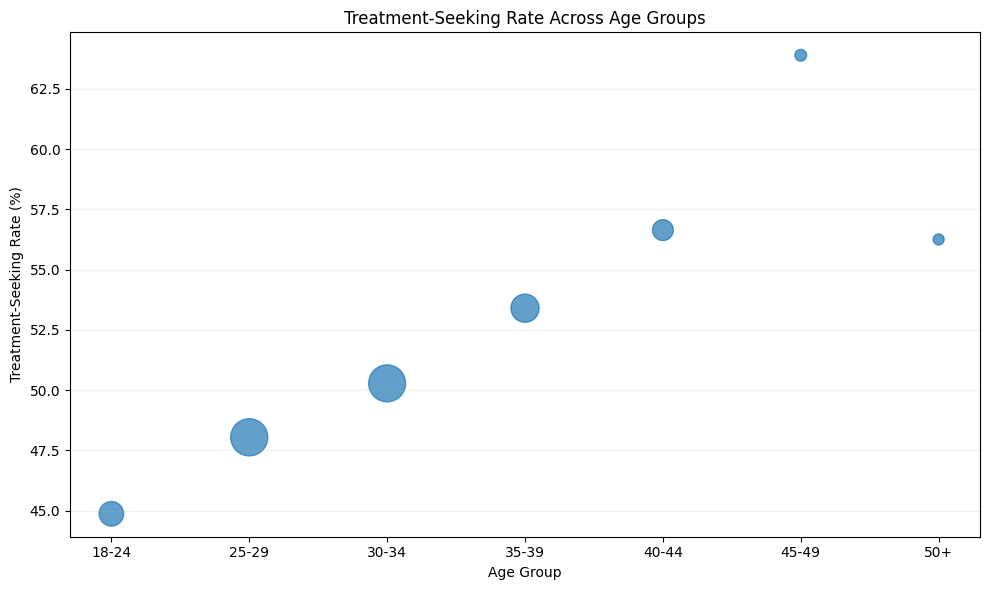

In [23]:
# Create age groups
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[17, 24, 29, 34, 39, 44, 49, 100],
    labels=[
        '18-24',
        '25-29',
        '30-34',
        '35-39',
        '40-44',
        '45-49',
        '50+'
    ]
)

# Calculate treatment rate and respondent count
age_treatment = df.groupby('Age Group', observed=True).agg(
    Treatment_Rate=('Treatment', lambda x: (x == 'Yes').mean() * 100),
    Respondents=('Treatment', 'count')
).reset_index()

# Bubble chart
plt.figure(figsize=(10, 6))

plt.scatter(
    age_treatment['Age Group'],
    age_treatment['Treatment_Rate'],
    s=age_treatment['Respondents'] * 2,
    alpha=0.7
)

plt.title('Treatment-Seeking Rate Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Treatment-Seeking Rate (%)')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

Finding

Treatment-seeking generally increases across the younger-to-middle age groups, rising from about 45% for ages 18–24 to above 55% for ages 40–44. The 45–49 group is highest at around 64%, although its bubble is relatively small, meaning fewer respondents are represented in that group.

Q18. How do age, treatment-seeking, and work interference vary together?

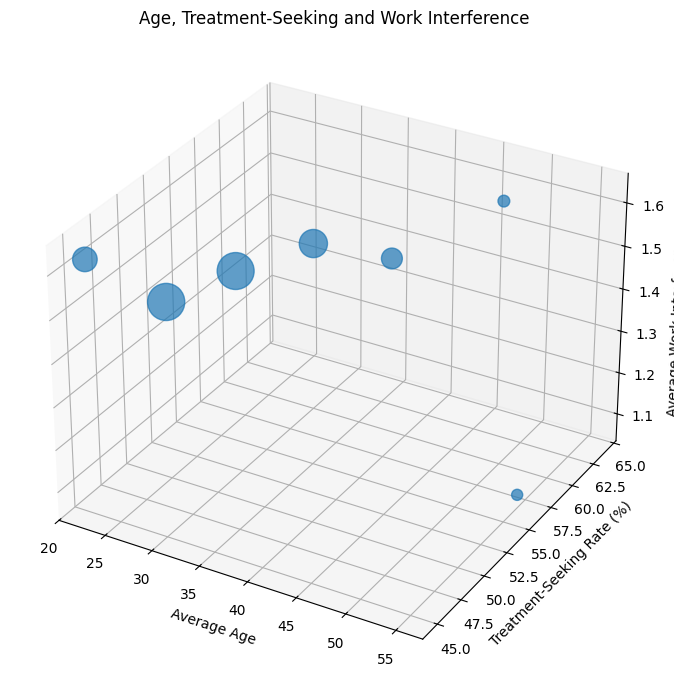

In [24]:
from mpl_toolkits.mplot3d import Axes3D

# Convert work interference into an ordered numerical score
work_score = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3
}

df['Work Interference Score'] = df['Work Interfere'].map(work_score)

# Create age-group summary
age_3d = df.groupby('Age Group', observed=True).agg(
    Average_Age=('Age', 'mean'),
    Treatment_Rate=('Treatment', lambda x: (x == 'Yes').mean() * 100),
    Avg_Work_Interference=('Work Interference Score', 'mean'),
    Respondents=('Age', 'count')
).dropna().reset_index()

# 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    age_3d['Average_Age'],
    age_3d['Treatment_Rate'],
    age_3d['Avg_Work_Interference'],
    s=age_3d['Respondents'] * 2,
    alpha=0.7
)

ax.set_title('Age, Treatment-Seeking and Work Interference')
ax.set_xlabel('Average Age')
ax.set_ylabel('Treatment-Seeking Rate (%)')
ax.set_zlabel('Average Work Interference Score')

plt.tight_layout()
plt.show()

Finding

The 3D view shows that treatment-seeking varies across age groups, while average work-interference scores remain within a relatively narrow range. The older age groups generally show higher treatment-seeking rates, but the smaller bubbles indicate fewer respondents in those groups.

Q19. How do treatment-seeking, remote work, and age vary across major respondent countries?

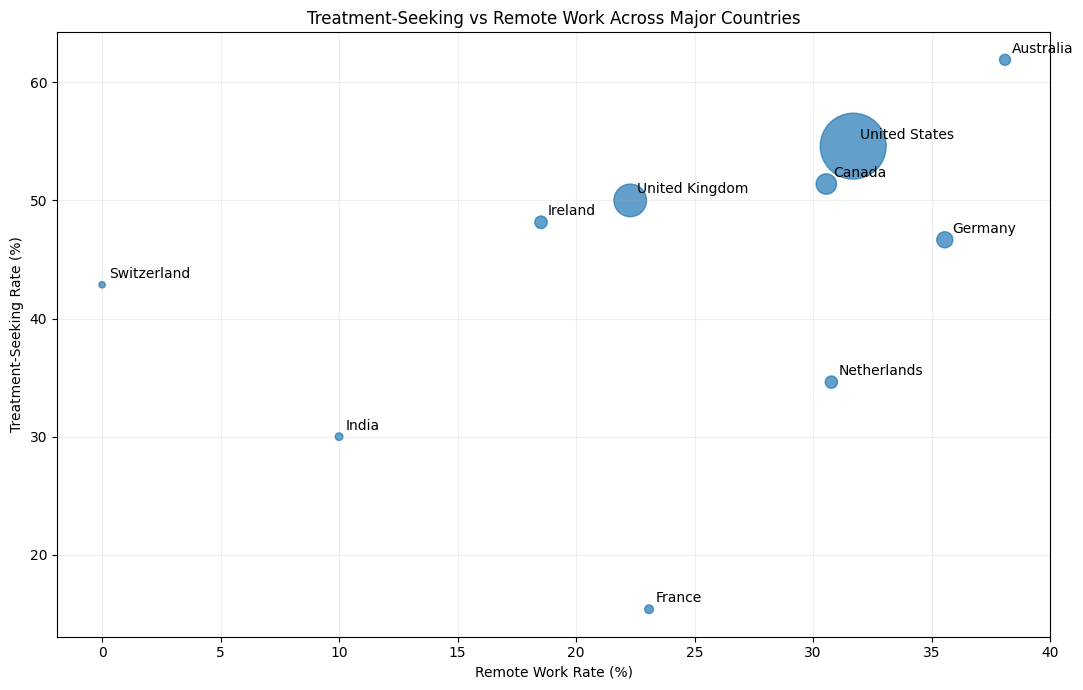

In [25]:
# Select top 10 countries by number of respondents
top_countries = df['Country'].value_counts().head(10).index

country_analysis = df[df['Country'].isin(top_countries)].groupby('Country').agg(
    Treatment_Rate=('Treatment', lambda x: (x == 'Yes').mean() * 100),
    Remote_Work_Rate=('Remote Work', lambda x: (x == 'Yes').mean() * 100),
    Average_Age=('Age', 'mean'),
    Respondents=('Age', 'count')
).reset_index()

plt.figure(figsize=(11, 7))

plt.scatter(
    country_analysis['Remote_Work_Rate'],
    country_analysis['Treatment_Rate'],
    s=country_analysis['Respondents'] * 3,
    alpha=0.7
)

# Add country labels
for _, row in country_analysis.iterrows():
    plt.annotate(
        row['Country'],
        (row['Remote_Work_Rate'], row['Treatment_Rate']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('Treatment-Seeking vs Remote Work Across Major Countries')
plt.xlabel('Remote Work Rate (%)')
plt.ylabel('Treatment-Seeking Rate (%)')

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()